In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import os

In [5]:
import so as so

In [6]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [7]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [8]:
import os

In [10]:
adata_raw = sc.read_h5ad('./soDGVAE_dataset/1_merfish_human_heart/human_heart_pc13_merfish.h5ad')
adata_raw

AnnData object with n_obs × n_vars = 228635 × 238
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity', 'region', 'subregion', 'region5', 'region4'
    uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'region4_colors', 'region5_colors', 'sample_id_colors', 'subregion_colors', 'umap', 'zone_cluster_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [16]:
data_list = [adata_raw[adata_raw.obs.loc[:, 'batch'] == batch, :] for batch in adata_raw.obs.loc[:, 'batch'].unique()]
data_list

[View of AnnData object with n_obs × n_vars = 72962 × 238
     obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity', 'region', 'subregion', 'region5', 'region4'
     uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'region4_colors', 'region5_colors', 'sample_id_colors', 'subregion_colors', 'umap', 'zone_cluster_colors'
     obsm: 'X_pca', 'X_umap', 'spatial'
     varm: 'PCs'
     obsp: 'connectivities', 'distances',
 View of AnnData object with n_obs × n_vars = 75782 × 238
     obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity', 'region', 'subregion', 'region5', 'region4'
     uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'region4_colors', 'region5_colors', 'sample_id_colors', 'subregion_colors', 'umap', 'zone_cluster_colors'
     obsm: 'X_pca', 'X_umap', 'spat

In [14]:
data_list[0].X.max()

1130.0

In [15]:
batch_names = files

In [16]:
batch_key = 'batch'
adata = so.pp.process_adata(data_list, label=batch_key, keys=batch_names, n_top_features=3000, target_sum=1e4)
adata

AnnData object with n_obs × n_vars = 227658 × 3000
    obs: 'X', 'Y', 'X_Scaled', 'Y_Scaled', 'Organ_Full_Name', 'clusters', 'Subregion', 'region', 'subregion', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'mu_bg', 'std_bg'
    obsm: 'spatial', 'spatial_scaled'
    layers: 'counts', 'norm_log'

In [45]:
rad_cutoff_list = [50] * len(data_list)
adata, g = so.pp.process_graph(adata, data_list, cutoff_list=rad_cutoff_list, model='KNN')

cal spatial net in data_list
------Calculating spatial graph...
The graph contains 3648100 edges, 72962 cells.
50.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 3789100 edges, 75782 cells.
50.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 3994550 edges, 79891 cells.
50.0000 neighbors per cell on average.


In [22]:
path_results = f'./log/result/'

In [70]:
adata_int = so.model.DGVAE(adata=adata,
                            n_epoch=2,
                            batch_size=1024,
                            verbose=False,
                            gpu=0,
                            random_seed=42,
                            output_dir=path_results,
                            num_heads=2,
                            h_dim=16,
                            reconstruct_loss='orig',
                            graph_loss=False,
                            )

clip
reconstruct_loss == orig


Epochs: 100%|█| 2/2 [00:26<00:00, 13.12s/it, recon_loss=544.4190, kl_loss=4.7686, mmd2=0.0000, graph_loss=0.0000, lr: 0.
Infer latent: 100%|███████████████████████████████████████████████████████████████████| 224/224 [00:02<00:00, 75.41it/s]


In [26]:
del adata_int.uns['adj']

In [27]:
adata_int.write_h5ad(f'{path_results}adata_int.h5ad', compression='gzip')

In [1]:
import scanpy as sc
import cupy as cp
import time
import rapids_singlecell as rsc
import warnings
warnings.filterwarnings("ignore")

/home/gzh/anaconda3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
import numpy as np
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

def compute_ARI(adata, anno_key, pred_key):
    return adjusted_rand_score(adata.obs[anno_key], adata.obs[pred_key])

def compute_NMI(adata, anno_key, pred_key):
    return normalized_mutual_info_score(adata.obs[anno_key], adata.obs[pred_key])

In [4]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [5]:
def kmeans_cluster(adata, n_clusters=10, used_embedding='X_pca', mode='KMeans', key_add='kmeans'):
    from sklearn.cluster import KMeans, MiniBatchKMeans
    if mode == 'KMeans':
        model = KMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(adata.obsm[used_embedding])
    elif mode == 'MiniBatchKMeans':
        model = MiniBatchKMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(
            adata.obsm[used_embedding])
    else:
        print('mode in [KMeans, MiniBatchKMeans]')
        raise NotImplementedError
    cell_label = model.labels_
    adata.obs.loc[:, key_add] = cell_label
    adata.obs.loc[:, key_add] = adata.obs.loc[:, key_add].astype(str)
    return adata

In [6]:
path_results = f'./log/integration_multi_organ_mini_radius005/'

In [7]:
adata_int = sc.read_h5ad(f'{path_results}adata_int.h5ad')
adata_int

AnnData object with n_obs × n_vars = 228635 × 238
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity', 'region', 'subregion', 'region5', 'region4', 'original_index', 'spot_quality', 'sub_kmeans', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg'
    obsm: 'X_pca', 'X_soDGVAE', 'X_umap', 'spatial'
    layers: 'counts', 'norm_log'

In [11]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=13, key_add='sub_kmeans')

CPU times: user 3.41 s, sys: 335 ms, total: 3.74 s
Wall time: 283 ms


AnnData object with n_obs × n_vars = 228635 × 238
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity', 'region', 'subregion', 'region5', 'region4', 'original_index', 'spot_quality', 'sub_kmeans', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_soDGVAE', 'X_umap', 'spatial'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

In [12]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=4, key_add='kmeans')

CPU times: user 2.44 s, sys: 82.2 ms, total: 2.52 s
Wall time: 150 ms


AnnData object with n_obs × n_vars = 228635 × 238
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity', 'region', 'subregion', 'region5', 'region4', 'original_index', 'spot_quality', 'sub_kmeans', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_soDGVAE', 'X_umap', 'spatial'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

... storing 'sub_kmeans' as categorical
... storing 'kmeans' as categorical


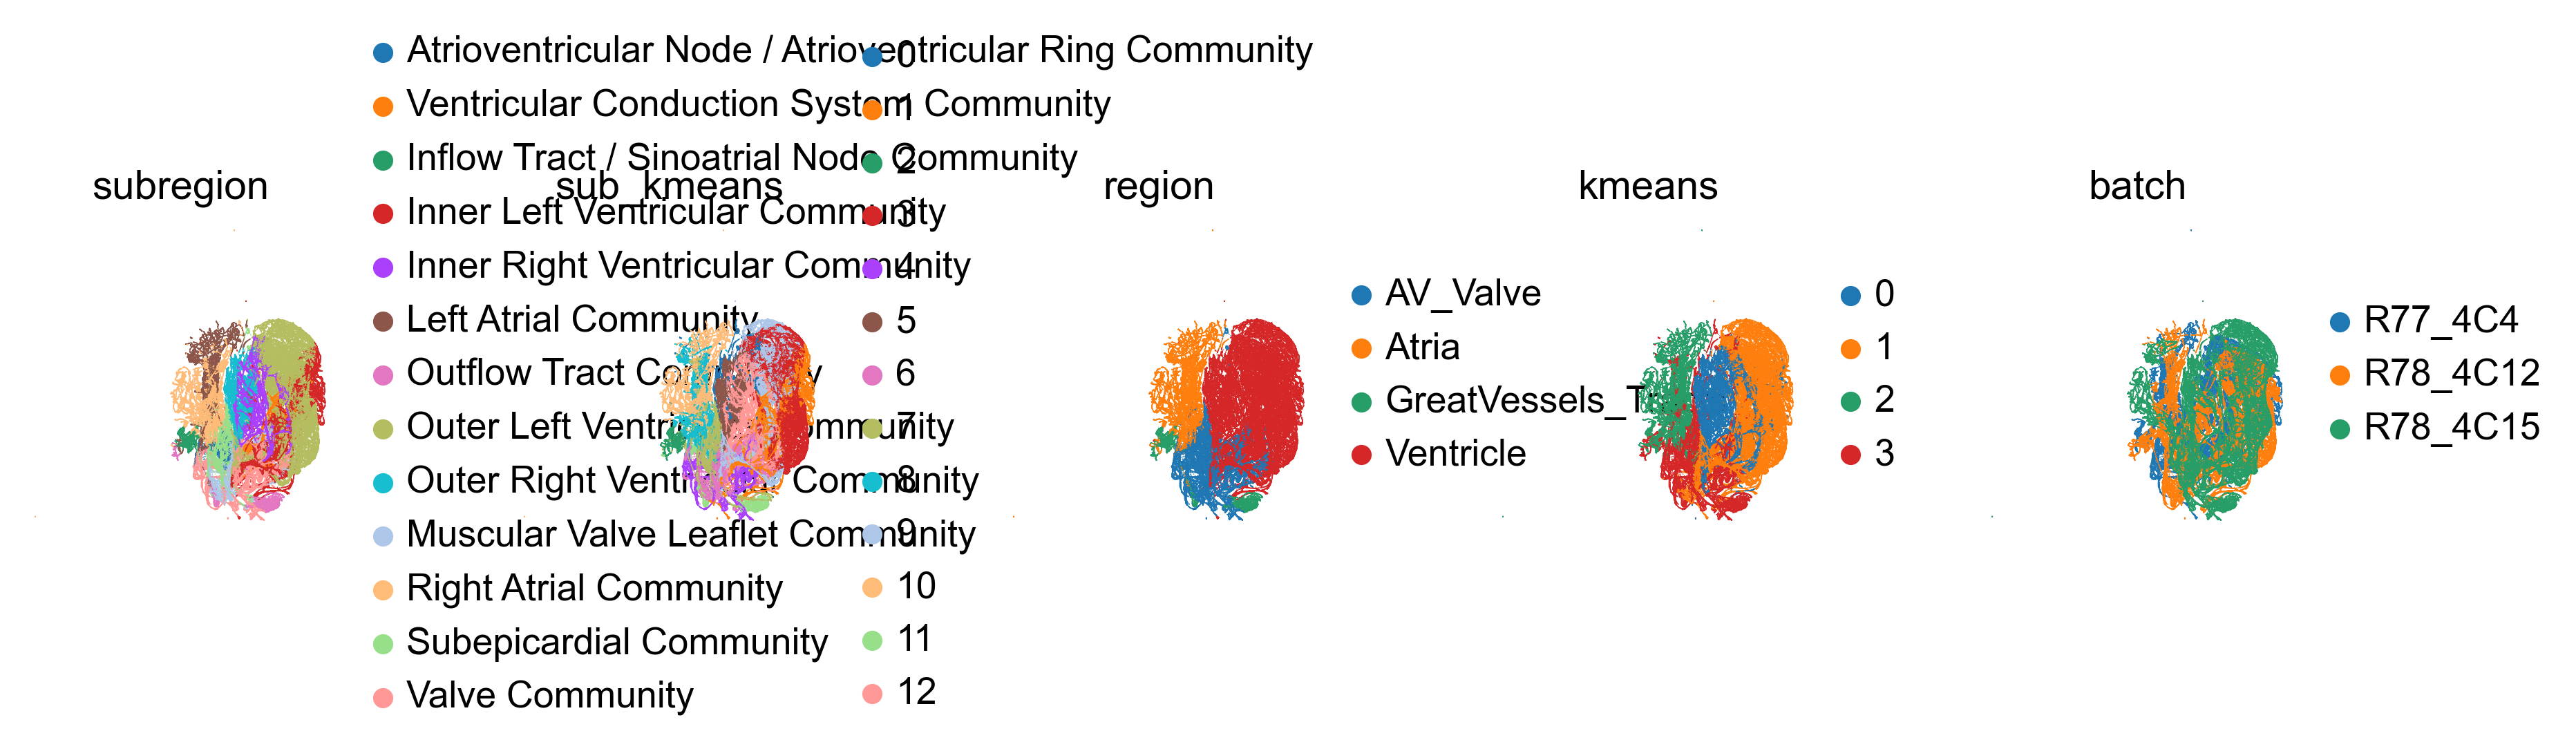

In [13]:
sc.pl.umap(adata_int, color=['subregion', 'sub_kmeans', 'region', 'kmeans', 'batch'], ncols=6)

In [14]:
batch_names = adata_int.obs.loc[:, 'batch'].unique()

R77_4C4


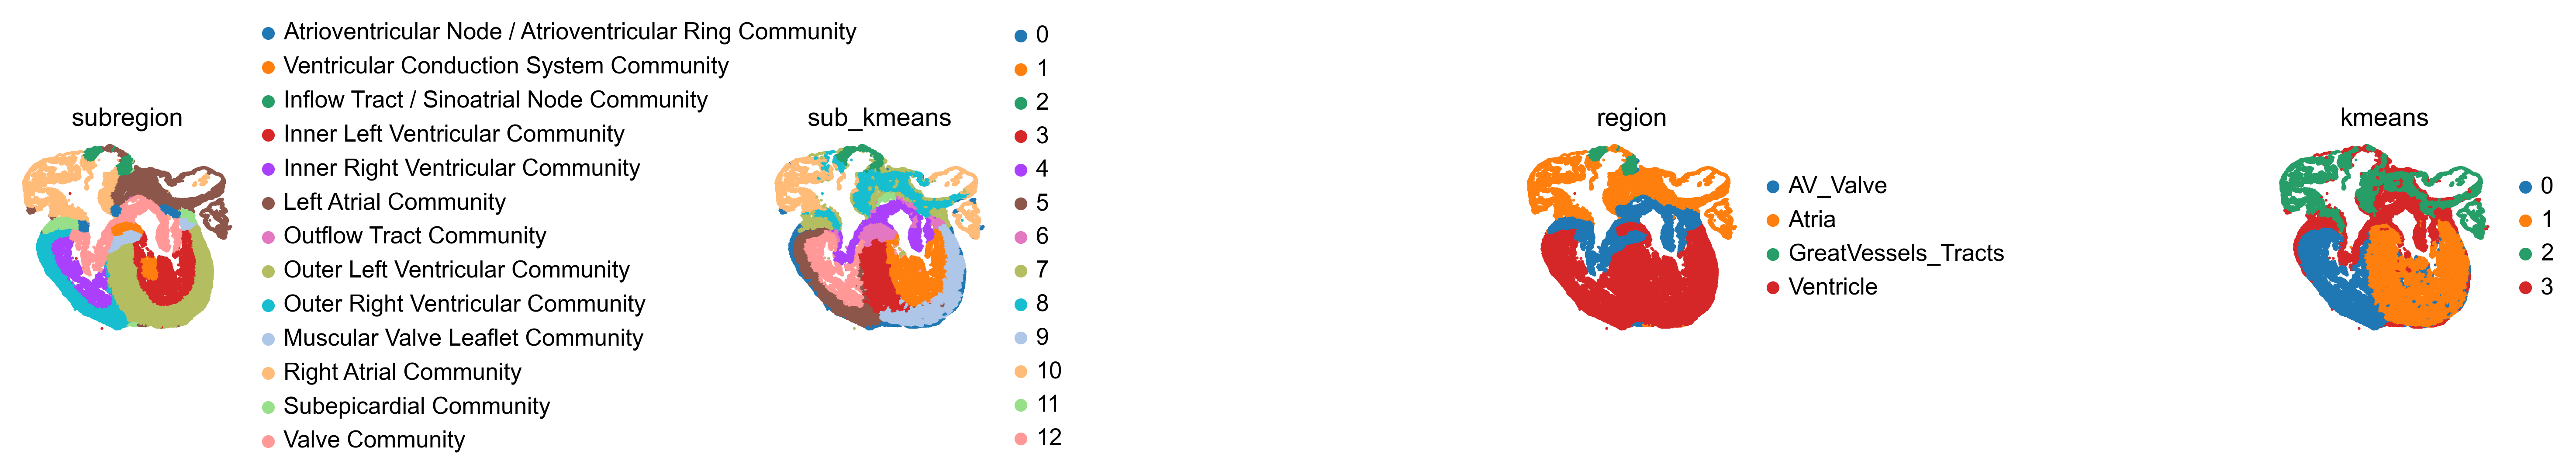

R78_4C12


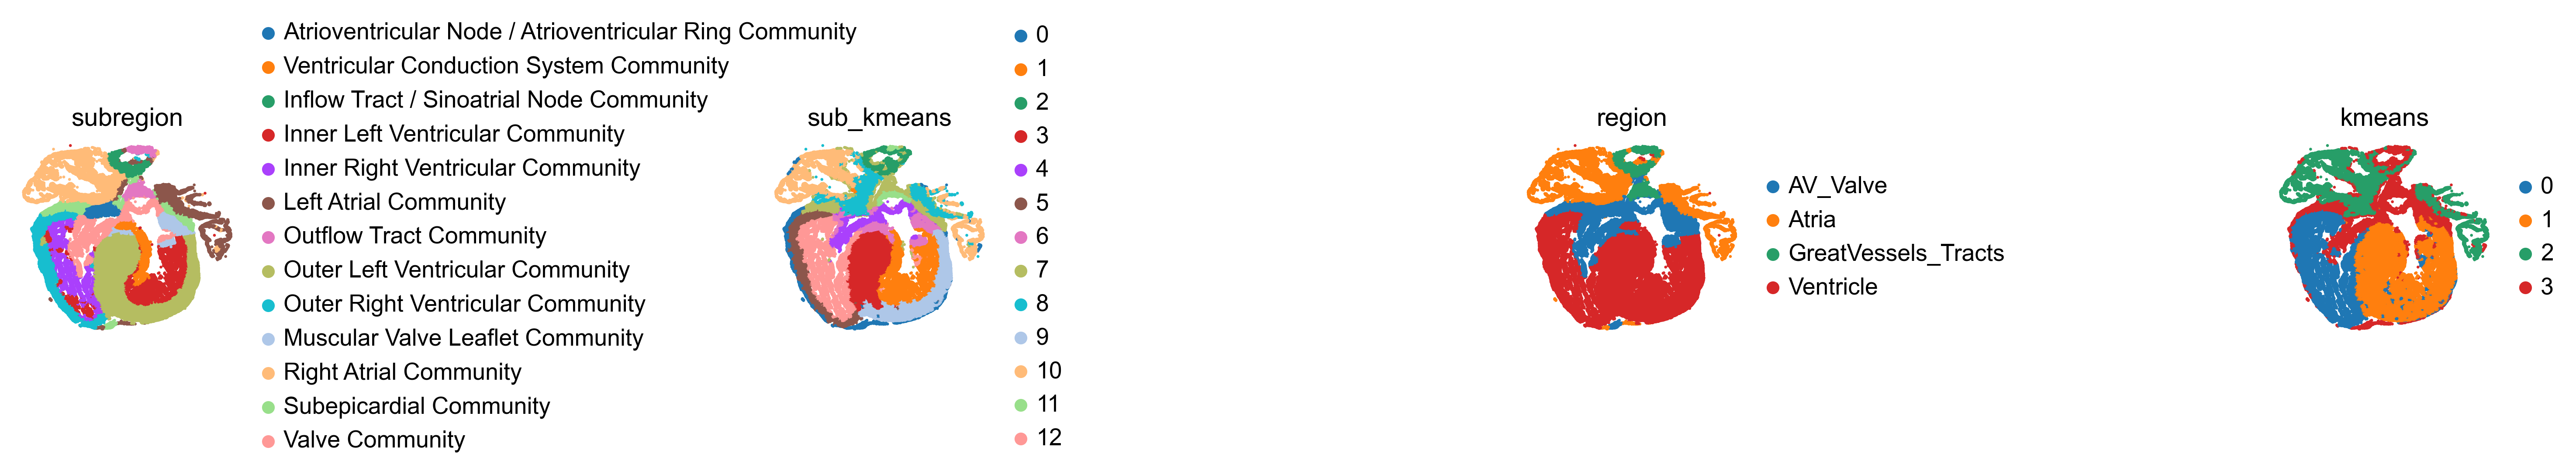

R78_4C15


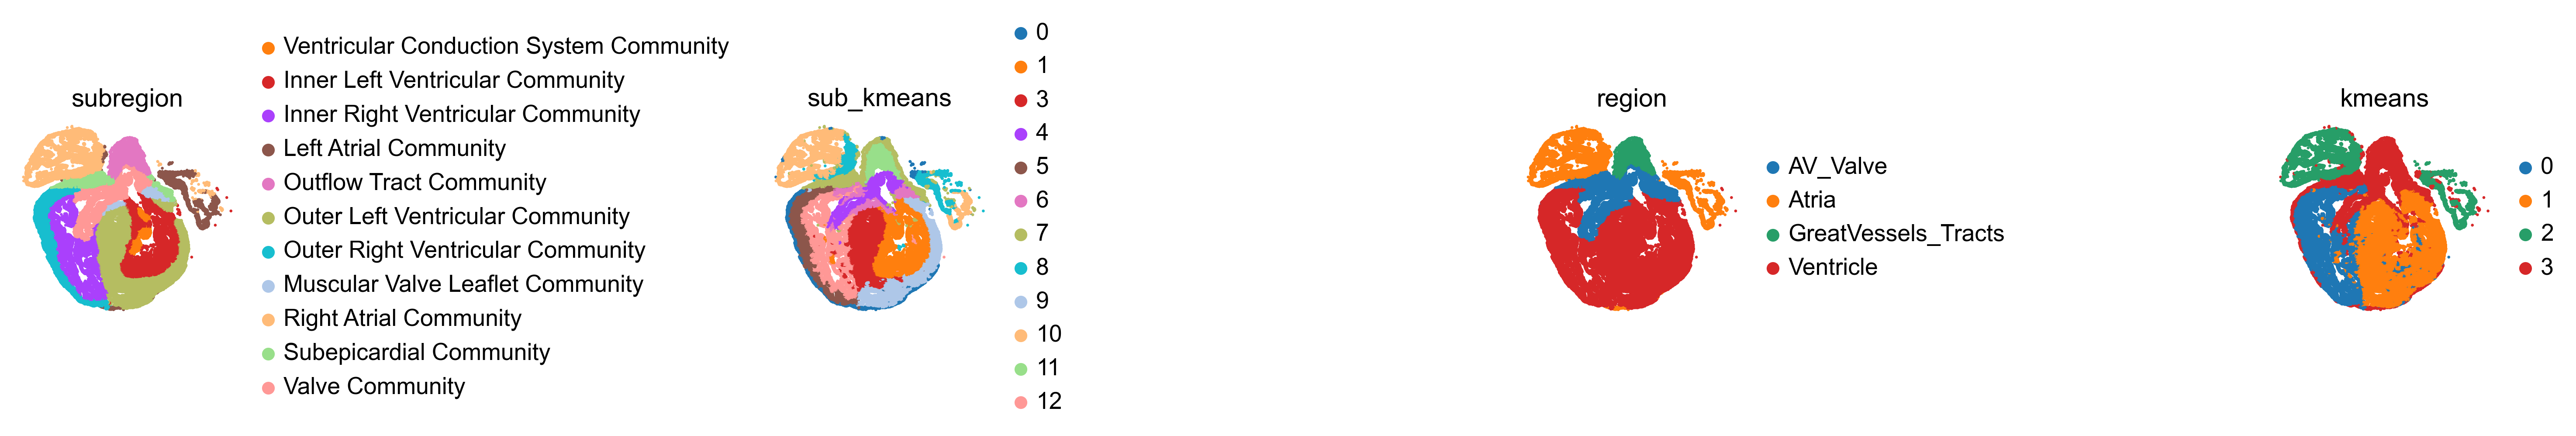

In [15]:
for batch in batch_names:
    temp = adata_int[adata_int.obs.loc[:, 'batch'] == batch, :]
    print(batch)
    sc.pl.embedding(temp, color=['subregion', 'sub_kmeans', 'region', 'kmeans'], ncols=5, basis='spatial', size=10, wspace=2)